This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment PASSIVE model to the multi-compartment one.

Here we use the normalized voltage, and the us as input to the neural network (time is not included!). We define u in a differential equation.

This notebook is a copy of nn_fitting_u_diff_no_t but trying to interrupt the simulation during training when the absolute difference from the target recording (x_o) is bigger than a treshold.

In [2]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)


import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax


import equinox as eqx
import flax.nnx as nnx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
t_max = 200.0
cut = 0

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"


# Define target
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)


all_setup = set_setup(setup)
cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])

simulate_multi = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_multi = simulate_multi()

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [4]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_passive_simulator,
    setup_passive_simulator_step,
    build_passive_cell,
    set_setup,
)

all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

simulate_single = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_single = simulate_single(x_o)[0]
np.save("../results/v_single.npy", v_single)


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [5]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_multi)) / (jnp.max(v_multi) - jnp.min(v_multi)) - 1
    

class SimpleNeuralNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension + 1, 32, rngs=rngs)
        #self.norm1 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear2 = nnx.Linear(32, 16, rngs=rngs)
        #self.norm2 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear3 = nnx.Linear(16, u_dimension, rngs=rngs)

    def __call__(self, inputs):
        x = self.linear1(inputs)
        x = jax.nn.relu(x)

        x = self.linear2(x)
        x = jax.nn.relu(x)
        return self.linear3(x)

class ReadoutNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension, 32, rngs=rngs)
        self.linear2 = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, u):
        u = self.linear1(u)
        u = jax.nn.relu(u)
        return self.linear2(u)
    
class CorrectionModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.neural_net = SimpleNeuralNet(rngs=rngs, u_dimension = u_dimension)
        self.readout_net = ReadoutNet(rngs=rngs, u_dimension = u_dimension)

    def __call__(self, u, v):
        u_new = self.neural_net(jnp.stack([u, v]))
        return self.readout_net(u_new)

In [6]:
dt = 0.025

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, u_time_constant, thr=30):
    def cond_fn(carry):
        t, _, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        inputs = jnp.concatenate([jnp.expand_dims(voltage_normalized, 0), u], axis=0)
        u_new = u - dt*neural_net(inputs) / u_time_constant #*0.02 #0.0008
        add_current = readout_net(u_new).squeeze()


        total_current = current[t] + add_current * added_curr_std #300 #40
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]

        new_recs, new_adds, new_us = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_recs, new_adds, new_us), new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (recs, adds, us), 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    t_final, _, _, (recs, adds, us), _ = final_carry

    return recs, adds, us

In [7]:
def loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant, thr = 30, reg_strength=0.0):
    preds, additional_currents, us = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_multi.squeeze(), added_curr_std, u_time_constant, thr
    )

    preds = preds.squeeze()
    v_multi = v_multi.squeeze()

    #maybe not computing the same loss again? it is computed as diff in the simulation
    
    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_multi) ** 2, nan = 0.0))
    reg_loss = reg_strength * jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan = 0.0)))


    total_loss = sse_loss + reg_loss
    return total_loss, (jnp.min(additional_currents), jnp.max(additional_currents), jnp.min(us), jnp.max(us))

In [8]:
rngs = nnx.Rngs(1)
u_dimension = 8
np.random.seed(42)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
model = CorrectionModel(rngs = rngs, u_dimension=u_dimension)

# Setup simulator
all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
initial_state, step_fn, current, time_vec = setup_passive_simulator_step(cell, t_max, all_setup["v_init"], i_amp)

added_curr_std = 1.0/150.0
u_time_constant = 100 #0.05


thr = 300

initial_lr = 10e-3  # 2e-1 for lbfgs?
decay_factor = 0.99 
transition_steps = 1  # decay after every epoch
#decay_until = 400  # after x epochs, stop decaying
decay_start = 600 
decay_end = 750 

# Normal exponential decay schedule
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

# Wrapped schedule that stops decaying after decay_until
# def clipped_schedule(step):
#     clipped_step = jnp.minimum(step, decay_until)
#     return raw_schedule(clipped_step)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

optimizer = optax.adam(learning_rate=custom_schedule)

# Other optimizers tried:
# optimizer = optax.sgd(learning_rate=clipped_schedule, momentum = 0.7)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1e6),  # Clip gradients
#     optax.sgd(learning_rate=clipped_schedule, momentum=0.5)
# )

# optimizer = optax.chain(
#     optax.scale_by_lbfgs(memory_size = 8), #6
#     optax.scale(-initial_lr),
# )

optimizer_state = nnx.Optimizer(model, optimizer)


def simulation_loss_fn(model):
        loss, (min_curr, max_curr, min_u, max_u) = loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant, thr)
        return loss, (min_curr, max_curr, min_u, max_u)


num_epochs = 1000
losses = []

grad_fn = nnx.jit(nnx.value_and_grad(simulation_loss_fn, has_aux=True))

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [9]:
# Saving the min and max currents and us in every epoch
min_currs = []
max_currs = []
min_us = []
max_us = []
for epoch in range(num_epochs):

    # if epoch == 500: #no int: 370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #no int: 8
    #         optax.scale(-0.1e-1), #no int: 0.3e-1
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    (loss, min_max), grads = grad_fn(optimizer_state.model)
    min_curr, max_curr, min_u, max_u = min_max
    min_currs.append(min_curr)
    max_currs.append(max_curr)
    min_us.append(min_u)
    max_us.append(max_u)


    optimizer_state.update(grads)

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
        # print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")
        # print(f"Min u: {jnp.min(inter_us)}, max u: {jnp.max(inter_us)}")
        # print(f"Min tnn: {jnp.min(inter_ts)}, max tnn: {jnp.max(inter_ts)}")
        # print("")

Epoch 0, Loss: 283.517440
Epoch 10, Loss: 281.856278
Epoch 20, Loss: 282.174673
Epoch 30, Loss: 284.954438
Epoch 40, Loss: 287.557383
Epoch 50, Loss: 287.744005
Epoch 60, Loss: 284.159860
Epoch 70, Loss: 286.865748
Epoch 80, Loss: 279.205453
Epoch 90, Loss: 290.283386
Epoch 100, Loss: 282.302636
Epoch 110, Loss: 286.879078
Epoch 120, Loss: 285.427828
Epoch 130, Loss: 284.516978
Epoch 140, Loss: 284.936647
Epoch 150, Loss: 284.695805
Epoch 160, Loss: 284.796599
Epoch 170, Loss: 284.927692
Epoch 180, Loss: 284.895893
Epoch 190, Loss: 284.973196
Epoch 200, Loss: 285.277899
Epoch 210, Loss: 285.113658
Epoch 220, Loss: 286.972128
Epoch 230, Loss: 285.093931
Epoch 240, Loss: 279.559933
Epoch 250, Loss: 292.464489
Epoch 260, Loss: 276.376226
Epoch 270, Loss: 274.497965
Epoch 280, Loss: 277.442007
Epoch 290, Loss: 295.889818
Epoch 300, Loss: 290.212602
Epoch 310, Loss: 284.487540
Epoch 320, Loss: 217.084552
Epoch 330, Loss: 161.614143
Epoch 340, Loss: 137.177626
Epoch 350, Loss: 115.790871
Epo

In [10]:
final_preds, final_additional_currents, final_us = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init,
    v_multi.squeeze(),
    added_curr_std,
    u_time_constant,
    thr = None
)


final_sse_loss = jnp.sum((final_preds.squeeze() - v_multi.squeeze())**2)
final_reg_loss = jnp.sum(final_additional_currents)

In [11]:
print("Final SSE loss: ", final_sse_loss, ", Final regulation loss: ", final_reg_loss)

Final SSE loss:  16.20316956026802 , Final regulation loss:  1145.3425726669605


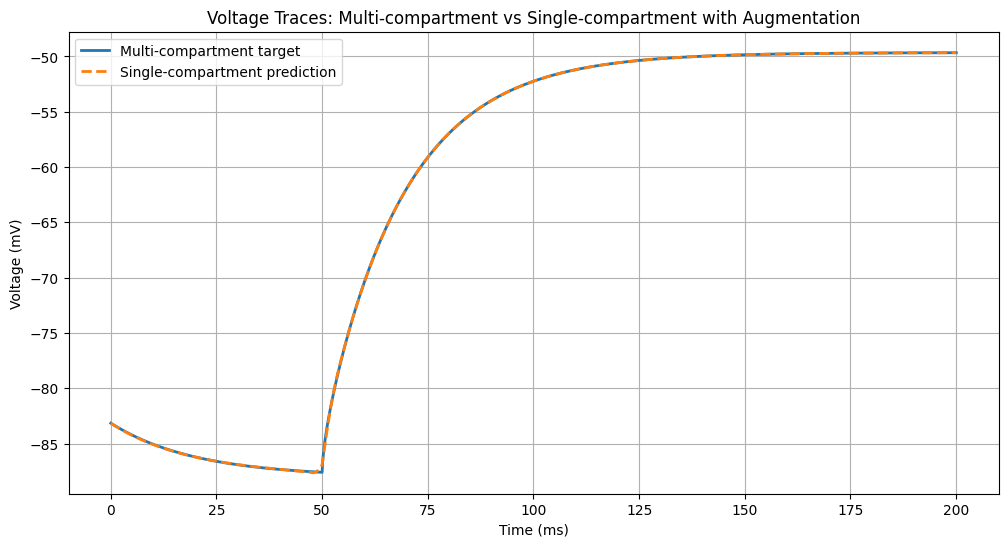

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec, v_multi[0], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

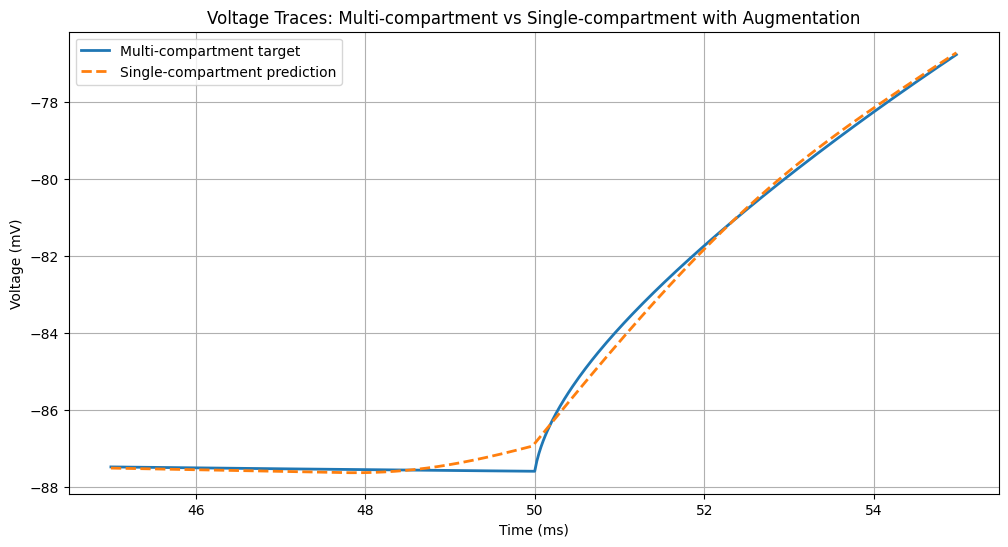

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec[1800:2200], v_multi[0][1800:2200], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec[1800:2200], final_preds[1800:2200], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

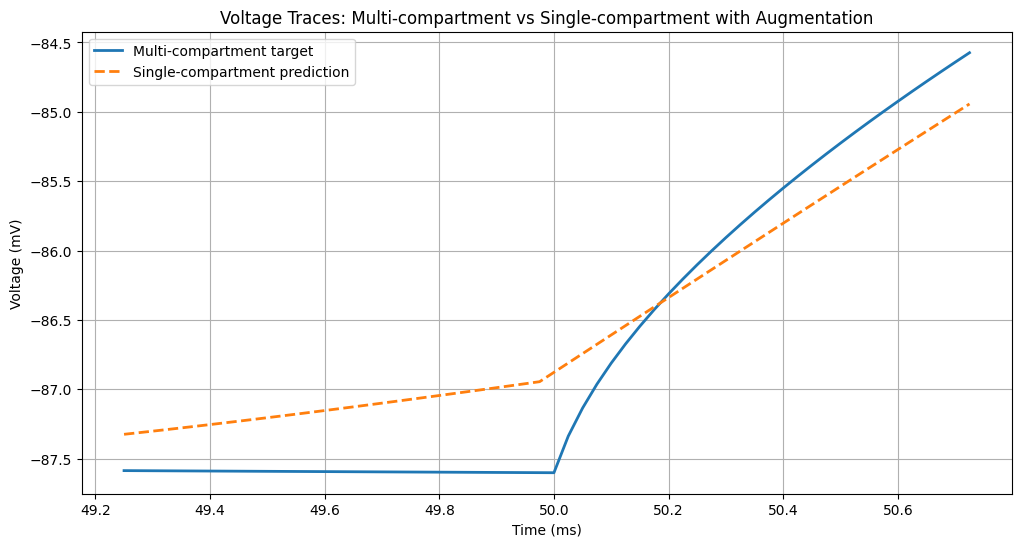

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec[1970:2030], v_multi[0][1970:2030], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec[1970:2030], final_preds[1970:2030], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

Text(0.5, 1.0, 'Additional current (mV)')

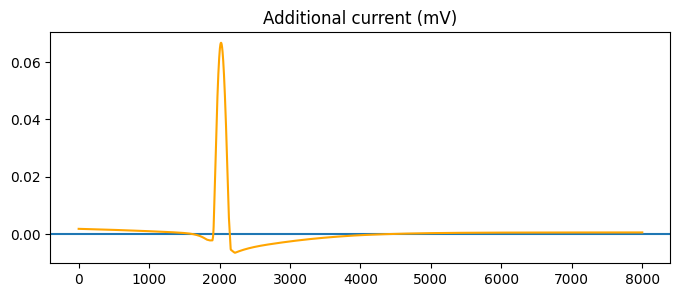

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
_ = ax.axhline(0.0)
_ = ax.plot(final_additional_currents * added_curr_std, color = "orange")
ax.set_title("Additional current (mV)")

In [20]:
np.save("../results/v_multi.npy", v_multi)
np.save("../results/no_t_interrupted_final_preds.npy", final_preds)
np.save("../results/no_t_interrupted_final_additional_currents.npy", final_additional_currents)
np.save("../results/no_t_interrupted_losses.npy", losses)

Text(0.5, 1.0, 'Minimum and maximum of the added currents throughout training')

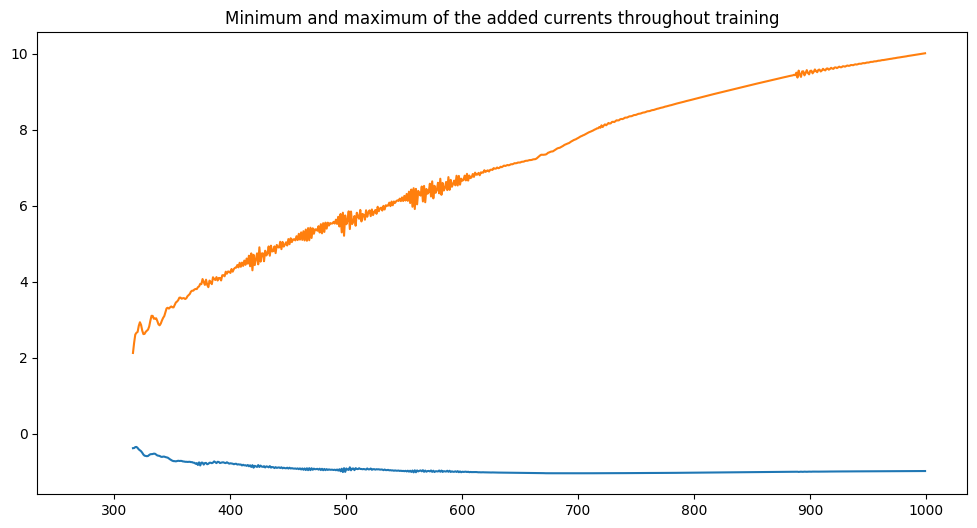

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(min_currs)
plt.plot(max_currs)
plt.title("Minimum and maximum of the added currents throughout training") #In the beginning there are nans because of the interruption

Text(0.5, 1.0, 'Minimum and maximum of the u values throughout training')

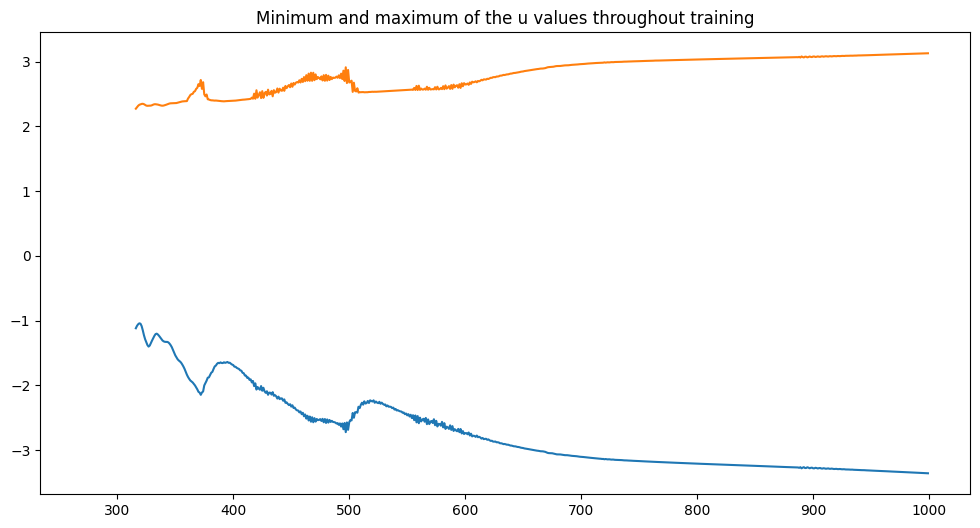

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(min_us)
plt.plot(max_us)
plt.title("Minimum and maximum of the u values throughout training")

Text(0.5, 1.0, 'Hidden state (u) dynamics after training, time_constant = 100')

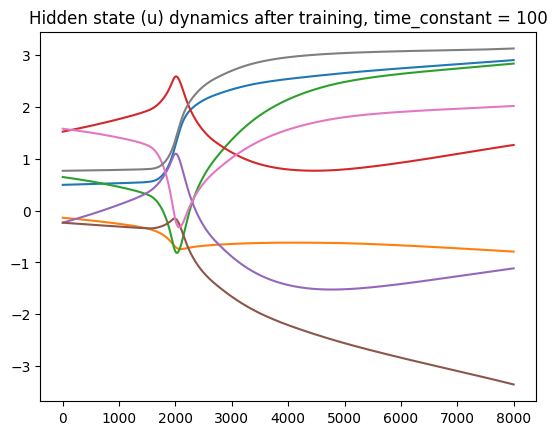

In [18]:
plt.plot(final_us)
plt.title("Hidden state (u) dynamics after training, time_constant = 100")